In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

c:\Users\user\Desktop\younes\data_exploration\uv_project


In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import calendar
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

from utilsforecast.plotting import plot_series as plot_series_utils
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(30)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

polars.config.Config

In [271]:
optional_service_mapping = {"MOD4": "MOD4AMA"}

In [ ]:
import lib
import importlib
importlib.reload(lib)

data = lib.read_smi_suiviexpedition_many()
data = data.filter(pl.date(2023, 1, 1) < pl.col("DATE_DERNIER_STATUT"))

In [273]:
print(data)

shape: (238_065, 9)
┌───────────────┬─────────────────────────────────┬─────────────────────┬─────────────────────────────┬───────────┬────────────────┬─────────────────────┬────────────────────────────────┬──────────────┐
│ CAB           ┆ CLIENT                          ┆ SERVICES_OPTIONNELS ┆ SITE_EXPEDITEUR             ┆ RECEPTION ┆ DERNIER_STATUT ┆ DATE_DERNIER_STATUT ┆ SITE_DERNIER_STATUT            ┆ DESTINATION  │
│ ---           ┆ ---                             ┆ ---                 ┆ ---                         ┆ ---       ┆ ---            ┆ ---                 ┆ ---                            ┆ ---          │
│ str           ┆ str                             ┆ str                 ┆ str                         ┆ str       ┆ str            ┆ datetime[ms]        ┆ str                            ┆ str          │
╞═══════════════╪═════════════════════════════════╪═════════════════════╪═════════════════════════════╪═══════════╪════════════════╪═════════════════════╪══════════════

In [274]:
series = (
    data.with_columns(ds="DATE_DERNIER_STATUT", unique_id="SITE_DERNIER_STATUT")
    .group_by_dynamic("ds", every="7d", by="unique_id")
    .having(pl.len() > 100)
    .agg(pl.len().alias("y"))
    .pipe(lib.complete_time_grid, "unique_id", "ds", "7d", "ms")
)

In [275]:
print(series.n_unique("unique_id"))

4


In [276]:
print(series.select(pl.col("y").sum()))

shape: (1, 1)
┌────────┐
│ y      │
│ ---    │
│ u32    │
╞════════╡
│ 216012 │
└────────┘


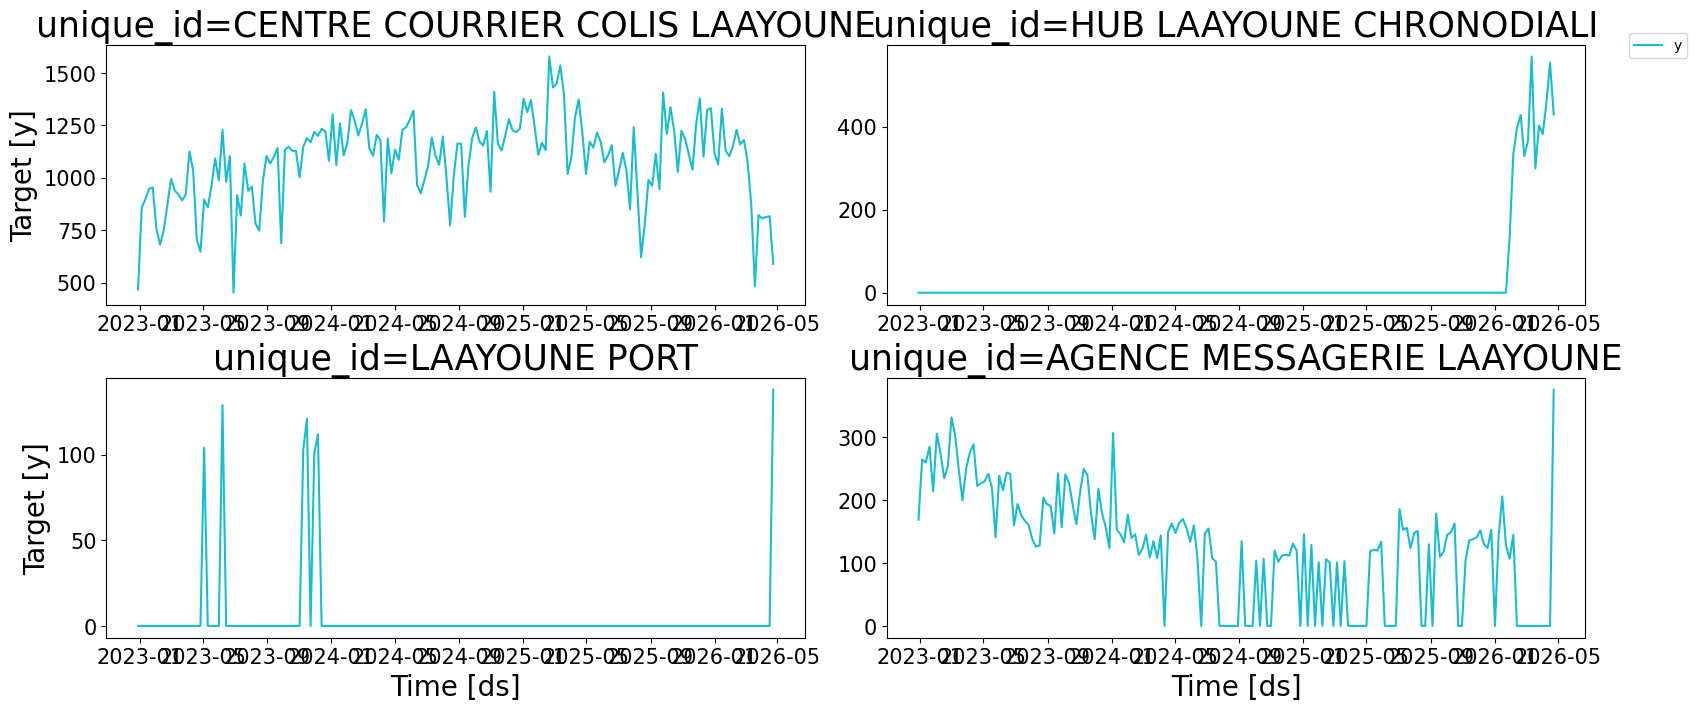

In [277]:
plot_series_stacked(series, max_ids=20)

In [278]:
services_optionnels_dummies = (
    data.with_columns(
        pl.col("SERVICES_OPTIONNELS")
        .str.split("-")
        .list.filter(pl.element() != "")
        .list.eval(pl.element().replace(optional_service_mapping))
        .list.sort()
    )
    .sort("SERVICES_OPTIONNELS")
    .explode("SERVICES_OPTIONNELS")
    .to_dummies("SERVICES_OPTIONNELS", drop_nulls=True, separator=":")
    .group_by("CAB")
    .max()
    .sort("DATE_DERNIER_STATUT")
)
print(services_optionnels_dummies.schema)

Schema({'CAB': String, 'CLIENT': String, 'SERVICES_OPTIONNELS:AR': UInt8, 'SERVICES_OPTIONNELS:CRCOUR': UInt8, 'SERVICES_OPTIONNELS:CRESPCCP': UInt8, 'SERVICES_OPTIONNELS:DAD': UInt8, 'SERVICES_OPTIONNELS:DTQ': UInt8, 'SERVICES_OPTIONNELS:ENVAMA': UInt8, 'SERVICES_OPTIONNELS:ENVBAMA': UInt8, 'SERVICES_OPTIONNELS:FRA': UInt8, 'SERVICES_OPTIONNELS:MOD1AMA': UInt8, 'SERVICES_OPTIONNELS:MOD1CAMA': UInt8, 'SERVICES_OPTIONNELS:MOD2AMA': UInt8, 'SERVICES_OPTIONNELS:MOD3AMA': UInt8, 'SERVICES_OPTIONNELS:MOD4AMA': UInt8, 'SERVICES_OPTIONNELS:MOD5AMA': UInt8, 'SERVICES_OPTIONNELS:MODPL': UInt8, 'SERVICES_OPTIONNELS:NDPSMS': UInt8, 'SERVICES_OPTIONNELS:POCAMA': UInt8, 'SERVICES_OPTIONNELS:POD': UInt8, 'SERVICES_OPTIONNELS:PODSMS': UInt8, 'SERVICES_OPTIONNELS:TRS': UInt8, 'SERVICES_OPTIONNELS:TRSNAT': UInt8, 'SERVICES_OPTIONNELS:VD': UInt8, 'SITE_EXPEDITEUR': String, 'RECEPTION': String, 'DERNIER_STATUT': String, 'DATE_DERNIER_STATUT': Datetime(time_unit='ms', time_zone=None), 'SITE_DERNIER_STATUT

In [347]:
corr = services_optionnels_dummies.select(
        pl.col(pl.NUMERIC_DTYPES).name.map(
            lambda c: c.replace("SERVICES_OPTIONNELS:", "")
        )
    ).to_pandas().corr(numeric_only=True)

threshold = 0.05

# remove self-correlation
np.fill_diagonal(corr.values, np.nan)

mask = (abs(corr) > threshold).any(axis=1)
result = corr.loc[mask, mask]

Text(0.5, 1.0, 'Correlation matrix between optional services')

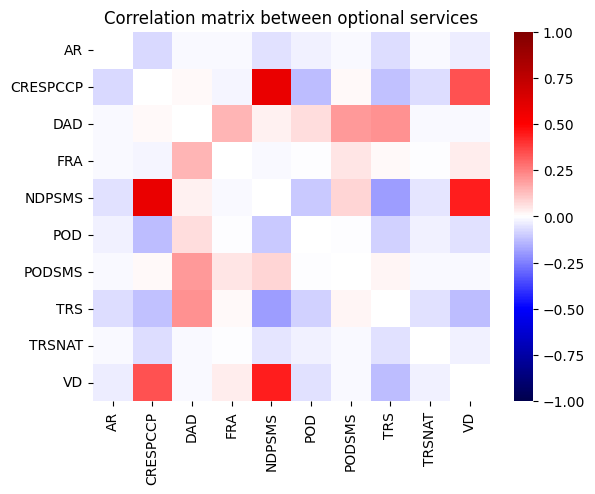

In [344]:
sns.heatmap(result, cmap="seismic", vmin=-1, vmax=1)
plt.title("Correlation matrix between optional services")

In [282]:

series = (
    services_optionnels_dummies.with_columns(
        ds="DATE_DERNIER_STATUT", unique_id=pl.lit("all")
    )
    .group_by_dynamic("ds", every="7d", by="unique_id")
    .agg(
        pl.col("^SERVICES_OPTIONNELS:(.*)$")
        .name.map(lambda c: c.replace("SERVICES_OPTIONNELS:", ""))
        .mean()
    )
    .pipe(lib.complete_time_grid, "unique_id", "ds", "7d", "ms")
)

In [283]:
print(series)

shape: (174, 24)
┌───────────┬─────────────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ unique_id ┆ ds                  ┆ AR       ┆ CRCOUR   ┆ CRESPCCP ┆ DAD      ┆ DTQ      ┆ ENVAMA   ┆ ENVBAMA ┆ FRA      ┆ MOD1AMA  ┆ MOD1CAMA ┆ MOD2AMA  ┆ MOD3AMA  ┆ MOD4AMA  ┆ MOD5AMA  ┆ MODPL    ┆ NDPSMS   ┆ POCAMA ┆ POD      ┆ PODSMS   ┆ TRS      ┆ TRSNAT   ┆ VD       │
│ ---       ┆ ---                 ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---    ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str       ┆ datetime[ms]        ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64     ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f6

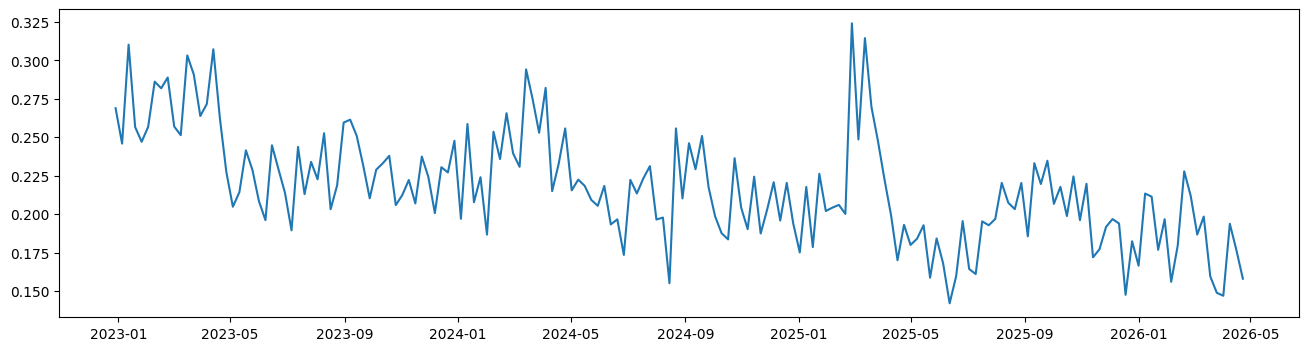

In [284]:
plt.subplots(figsize=(16, 4))
plt.plot(series["ds"], series["TRS"])

<Axes: >

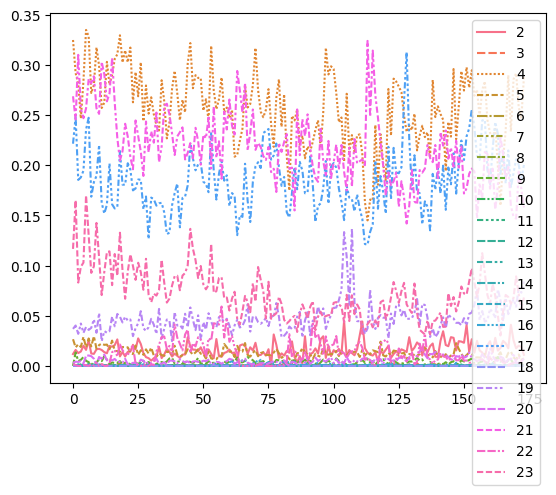

In [285]:
sns.lineplot(series)